Dataset Shape: (10000, 10)
   study_hours  sleep_hours  screen_time  exercise_minutes  tasks_completed  \
0         6.39         4.15         2.93             26.79                3   
1         0.30         5.31         4.54              3.18                6   
2         2.78         9.22         6.31             19.16               13   
3         0.93         4.58         6.93             72.45                1   
4         5.52         8.98         5.33            103.40                6   

   water_intake_liters  break_time_minutes  focus_score  productivity_score  \
0                 2.87              107.06         1.78               67.99   
1                 3.01               84.16         4.78               52.82   
2                 1.69               18.66         9.61              100.65   
3                 3.05               64.35         9.76               64.70   
4                 2.97                5.50         3.05               86.76   

   productive  
0      

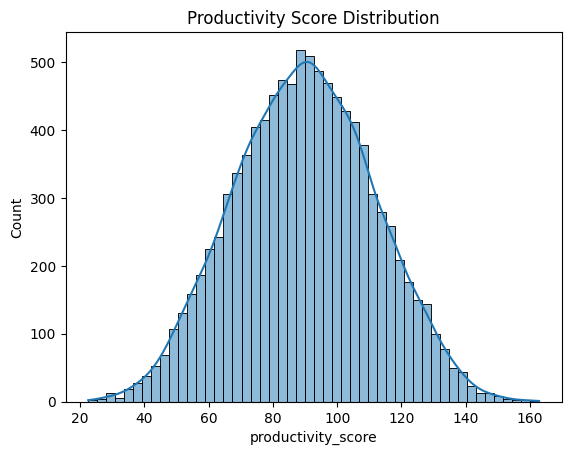

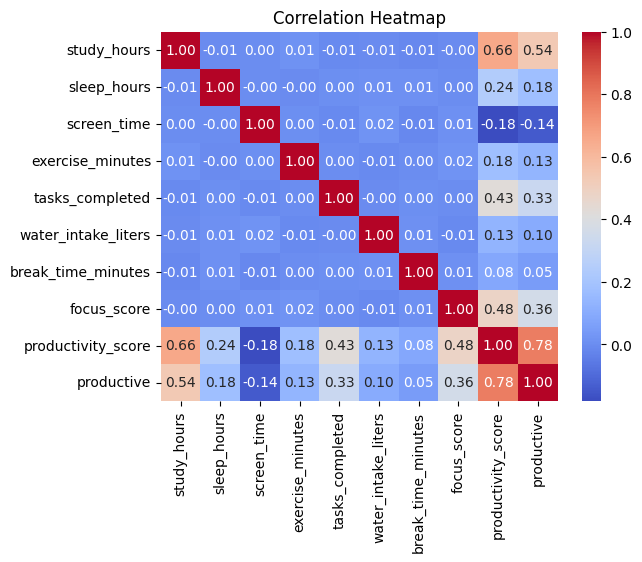


Logistic Regression Accuracy: 0.9835
Random Forest Accuracy: 0.949
Gradient Boosting Accuracy: 0.9495

Classification Report (RF):
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       657
           1       0.95      0.98      0.96      1343

    accuracy                           0.95      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.95      0.95      0.95      2000



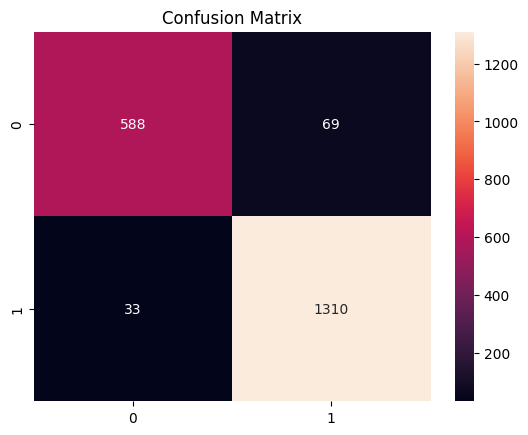

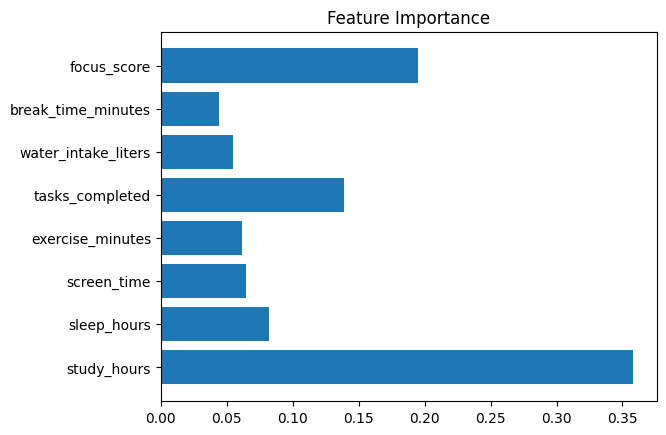

 99%|===================| 3968/4000 [01:25<00:00]        

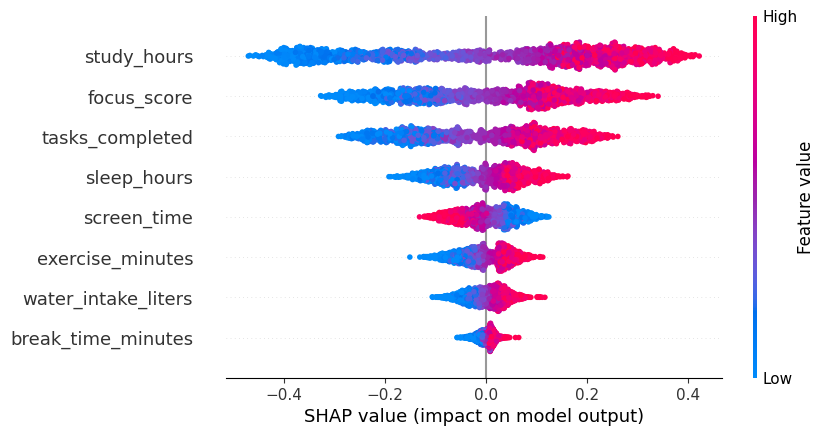

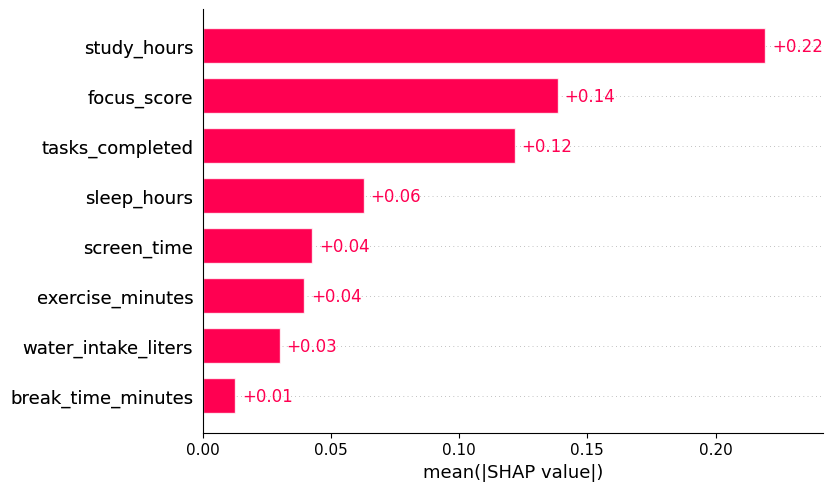

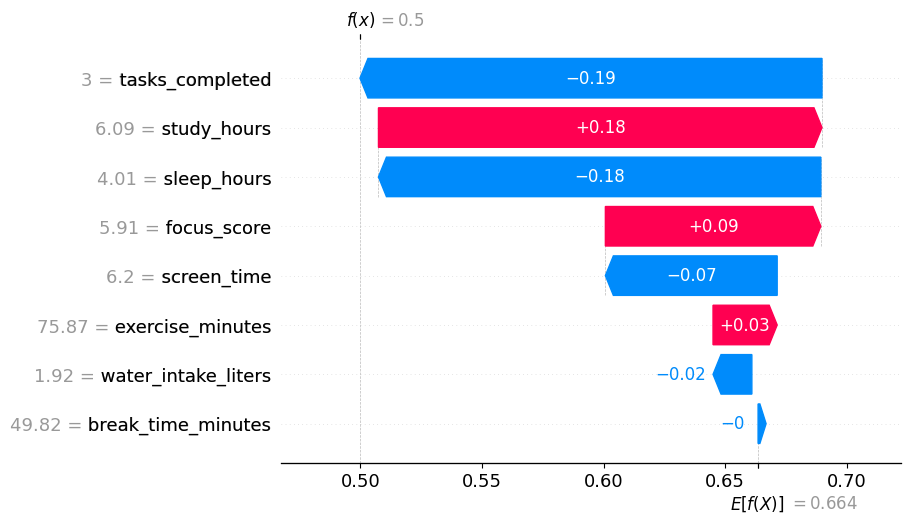


Insights Example:
['Low sleep is reducing productivity', 'Reduce screen time']

Enter your daily habits 👇

📊 FINAL RESULT:
Prediction: Productive ✅
Confidence: 68.0 %

🧠 Insights:
- Reduce screen time
- Exercise more
✅ Model + Feature order saved successfully!


In [5]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ===============================
# 2. Load Dataset
# ===============================
data = pd.read_excel("habit_productivity_dataset_v2 (1).xlsx")

print("Dataset Shape:", data.shape)
print(data.head())

# ===============================
# 3. Data Visualization
# ===============================

plt.figure()
sns.histplot(data["productivity_score"], kde=True)
plt.title("Productivity Score Distribution")
plt.show()

plt.figure()
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 4. Define Features & Target
# ===============================
X = data.drop(["productivity_score", "productive"], axis=1)
y = data["productive"]

# ===============================
# 5. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 6. Feature Scaling (for LR)
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 7. Train Models
# ===============================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# ===============================
# 8. Predictions
# ===============================
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

# ===============================
# 9. Evaluation
# ===============================
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification Report (RF):")
print(classification_report(y_test, y_pred_rf))

# ===============================
# 10. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 11. Feature Importance
# ===============================
importances = rf.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

# ===============================
# 12. SHAP (Explainability)
# ===============================
explainer = shap.Explainer(rf, X_train)

shap_values = explainer(X_test, check_additivity=False)

# Fix multi-class issue
shap_values_class1 = shap_values[:, :, 1]

shap.plots.beeswarm(shap_values_class1)
shap.plots.bar(shap_values_class1)
shap.plots.waterfall(shap_values_class1[0])

# ===============================
# 13. Rule-Based Insights
# ===============================
def generate_insights(input_data):
    insights = []

    if input_data["sleep_hours"] < 6:
        insights.append("Low sleep is reducing productivity")

    if input_data["study_hours"] < 3:
        insights.append("Increase study hours")

    if input_data["screen_time"] > 5:
        insights.append("Reduce screen time")

    if input_data["exercise_minutes"] < 20:
        insights.append("Exercise more")

    if input_data["focus_score"] < 5:
        insights.append("Improve focus")

    return insights

# Example
sample = X_test.iloc[0].to_dict()
print("\nInsights Example:")
print(generate_insights(sample))
# 11. RUN INPUT + PREDICTION
# ===============================
user_input = get_user_input()

input_df = pd.DataFrame([user_input])
input_df = input_df[X.columns]   # 🔥 IMPORTANT

prediction = rf.predict(input_df)[0]
probability = rf.predict_proba(input_df)[0][1]

print("\n📊 FINAL RESULT:")
print("Prediction:", "Productive ✅" if prediction == 1 else "Not Productive ❌")
print("Confidence:", round(probability * 100, 2), "%")

# ===============================
# 12. SHOW INSIGHTS
# ===============================
print("\n🧠 Insights:")

insights = generate_insights(user_input)

if len(insights) == 0:
    print("✅ Your habits are excellent!")
else:
    for i in insights:
        print("-", i)
# ===============================
# 14. SAVE MODEL + FEATURE ORDER
# ===============================
joblib.dump(rf, "productivity_model.pkl")

# 🔥 MOST IMPORTANT FIX
joblib.dump(X.columns.tolist(), "feature_order.pkl")

print("✅ Model + Feature order saved successfully!")